# FIFA World Cup 2022 Match Exploratory Data Analysis

## Project Goal
This project uses exploratory data analysis (EDA) to analyze match statistics from FIFA World Cup 22 to identify features correlated with the match outcomes such as possession, shots on target, and goal prevention.

## Dataset
The dataset used in this analysis was sourced from [Kaggle](https://www.kaggle.com/datasets/die9origephit/fifa-world-cup-2022-complete-dataset?resource=download) and contains match statistics from the FIFA World Cup 2022.

## Importing Needed Libraries

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

## Data Loading

In [2]:
df = pd.read_csv("../data/raw/Fifa_world_cup_matches.csv")
pd.set_option('display.max_columns', None)
df.head()

,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,total attempts team1,total attempts team2,conceded team1,conceded team2,goal inside the penalty area team1,goal inside the penalty area team2,goal outside the penalty area team1,goal outside the penalty area team2,assists team1,assists team2,on target attempts team1,on target attempts team2,off target attempts team1,off target attempts team2,attempts inside the penalty area team1,attempts inside the penalty area team2,attempts outside the penalty area team1,attempts outside the penalty area team2,left channel team1,left channel team2,left inside channel team1,left inside channel team2,central channel team1,central channel team2,right inside channel team1,right inside channel team2,right channel team1,right channel team2,total offers to receive team1,total offers to receive team2,inbehind offers to receive team1,inbehind offers to receive team2,inbetween offers to receive team1,inbetween offers to receive team2,infront offers to receive team1,infront offers to receive team2,receptions between midfield and defensive lines team1,receptions between midfield and defensive lines team2,attempted line breaks team1,attempted line breaks team2,completed line breaksteam1,completed line breaks team2,attempted defensive line breaks team1,attempted defensive line breaks team2,completed defensive line breaksteam1,completed defensive line breaks team2,yellow cards team1,yellow cards team2,red cards team1,red cards team2,fouls against team1,fouls against team2,offsides team1,offsides team2,passes team1,passes team2,passes completed team1,passes completed team2,crosses team1,crosses team2,crosses completed team1,crosses completed team2,switches of play completed team1,switches of play completed team2,corners team1,corners team2,free kicks team1,free kicks team2,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,5,6,2,0,0,2,0,0,0,1,0,3,5,3,2,4,3,2,15,8,0,7,3,6,1,4,9,6,520,532,116,127,235,187,169,218,5,8,136,155,86,99,9,13,4,7,4,2,0,0,15,15,3,4,450,480,381,409,9,14,4,4,9,9,1,3,19,17,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,13,8,2,6,6,2,0,0,6,1,7,3,3,4,10,6,3,2,11,3,5,0,2,3,3,1,11,0,1061,212,207,53,386,86,468,73,16,4,238,101,178,45,25,7,16,4,0,2,0,0,9,14,2,2,809,224,730,154,23,8,7,1,12,3,8,0,16,10,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,14,9,2,0,0,2,0,0,0,1,3,3,8,5,7,5,7,4,12,11,4,2,2,2,4,7,13,20,502,506,123,117,230,191,149,198,15,14,151,162,89,96,22,22,15,10,2,1,0,0,13,13,2,1,383,438,313,374,19,25,7,8,9,6,6,7,14,14,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,6,7,1,1,1,1,0,0,1,0,1,3,4,3,4,5,2,2,14,7,5,2,4,5,4,2,11,7,725,436,149,100,336,172,240,164,12,9,199,174,146,103,23,17,15,8,4,2,0,0,15,10,1,1,569,409,509,321,31,15,4,6,5,8,5,3,11,15,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,14,3,2,1,1,2,0,0,0,1,6,2,5,0,10,3,4,0,12,3,4,2,5,3,8,3,18,8,650,268,157,69,177,131,316,68,26,9,191,137,127,68,39,15,25,7,0,6,0,0,7,21,10,1,610,267,529,190,29,9,12,2,5,7,9,2,22,16,1,0,4,14,0,0,65,80,163,361


## Initial Data Inspection

In [3]:
df.shape
df.info()
df.isnull().sum()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 88 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   team1                                                  64 non-null     object
 1   team2                                                  64 non-null     object
 2   possession team1                                       64 non-null     object
 3   possession team2                                       64 non-null     object
 4   possession in contest                                  64 non-null     object
 5   number of goals team1                                  64 non-null     int64 
 6   number of goals team2                                  64 non-null     int64 
 7   date                                                   64 non-null     object
 8   hour                                                   64 non-

Index(['team1', 'team2', 'possession team1', 'possession team2',
       'possession in contest', 'number of goals team1',
       'number of goals team2', 'date', 'hour', 'category',
       'total attempts team1', 'total attempts team2', 'conceded team1',
       'conceded team2', 'goal inside the penalty area team1',
       'goal inside the penalty area team2',
       'goal outside the penalty area team1',
       'goal outside the penalty area team2', 'assists team1', 'assists team2',
       'on target attempts team1', 'on target attempts team2',
       'off target attempts team1', 'off target attempts team2',
       'attempts inside the penalty area team1',
       'attempts inside the penalty area  team2',
       'attempts outside the penalty area  team1',
       'attempts outside the penalty area  team2', 'left channel team1',
       'left channel team2', 'left inside channel team1',
       'left inside channel team2', 'central channel team1',
       'central channel team2', 'right in

There are no missing values, so there is no need to handle them. 
In this dataset, there are 8 columns that contain object data: 'team1', 'team2', 'possession team1', 'possession team2', 'possession in contest', 'date', 'hour', and 'category'.  
Out of these columns, the following three should be converted to numeric values, and the percentage sign should be removed: 'possession team1', 'possession team2', and 'possession in contest'. 

## Data Cleaning & Pre-processing
Before performing analysis, we clean and standardize the dataset.  
This step ensures consistent column names, correct data types, and easier feature manipulation. This includes: 

- adding a 'result' column
- fixing broken column names
- removing the '%' sign
- convert percentage columns to numeric values

In [4]:

# adding 'result' column
def get_result(row): 
    if row['number of goals team1'] > row['number of goals team2']: 
        return 1      # win for team 1
    elif row['number of goals team1'] == row['number of goals team2']: 
        return 0      # draw 
    else: 
        return -1     # loss for team 1 

df['result'] = df.apply(get_result, axis = 1) # apply for each row
df[['team1', 'team2', 'number of goals team1', 'number of goals team2', 'result']].head()

,team1,team2,number of goals team1,number of goals team2,result
0,QATAR,ECUADOR,0,2,-1
1,ENGLAND,IRAN,6,2,1
2,SENEGAL,NETHERLANDS,0,2,-1
3,UNITED STATES,WALES,1,1,0
4,ARGENTINA,SAUDI ARABIA,1,2,-1


In [5]:
# standardizing column names 
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
# fixing broken column names
df = df.rename(columns = {
    'completed_line_breaksteam1': 'completed_line_breaks_team1', 
    'completed_defensive_line_breaksteam1': 'completed_defensive_line_breaks_team1'
})
# removing '%' and converting to numeric values 
percent_cols = ['possession_team1', 'possession_team2', 'possession_in_contest']
for col in percent_cols:
    df[col] = df[col].str.replace('%', '').astype(float)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 89 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   team1                                                  64 non-null     object 
 1   team2                                                  64 non-null     object 
 2   possession_team1                                       64 non-null     float64
 3   possession_team2                                       64 non-null     float64
 4   possession_in_contest                                  64 non-null     float64
 5   number_of_goals_team1                                  64 non-null     int64  
 6   number_of_goals_team2                                  64 non-null     int64  
 7   date                                                   64 non-null     object 
 8   hour                                                

## Exploratory Data Analysis

### Match Result Distribution 

In [7]:
df['result'].value_counts()

result
 1    29
-1    20
 0    15
Name: count, dtype: int64

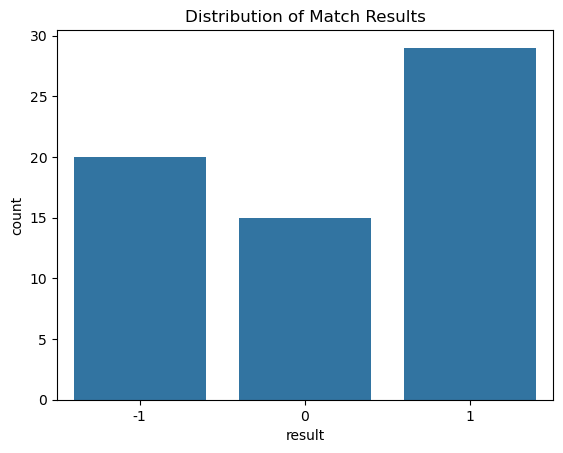

In [8]:
sns.countplot(x='result', data=df)
plt.title("Distribution of Match Results") 
plt.show()

The output of the above two cells show that most matches ended with a definitive clear winner, while draws were relatively less frequent. 

### Goals Distribution 

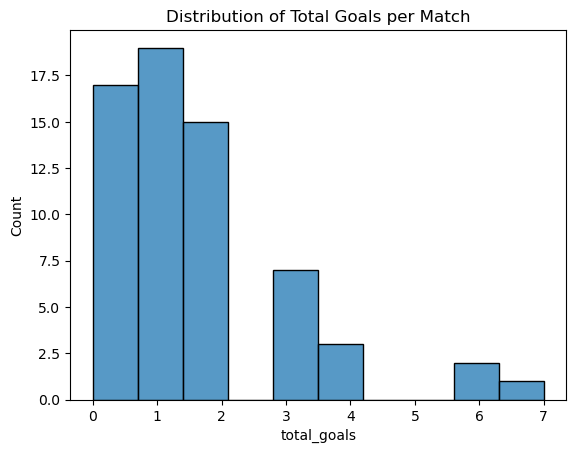

In [9]:
df['total_goals'] = df['number_of_goals_team1']
sns.histplot(df['total_goals'], bins=10)
plt.title('Distribution of Total Goals per Match')
plt.show()

Most matches in this version of World Cup had between 1 to 3 total goals. 

### Attacking Performance vs Match Result
To understand how attacking performance influences match outcomes, we analyze three metrics:

- Shots on target
- Shot accuracy
- Goal conversion rate

These metrics measure both the volume and efficiency of attacking opportunities. 

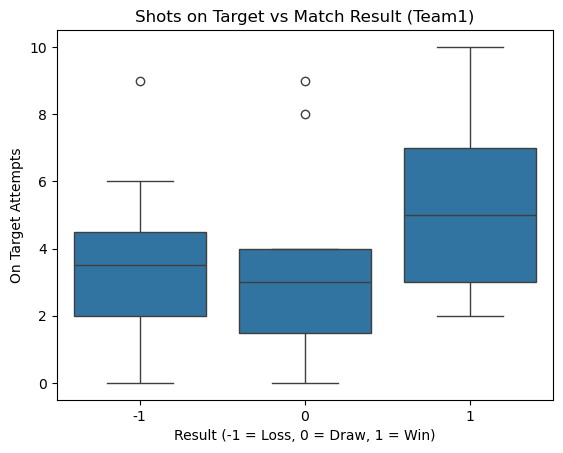

In [10]:
sns.boxplot(x='result', y='on_target_attempts_team1', data=df)
plt.title('Shots on Target vs Match Result (Team1)')
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel('On Target Attempts')
plt.savefig("../images/shots_on_target_vs_result.png", dpi=300)
plt.show()

The **shots on target** plot shows that winning teams generally produce a higher number of shots on target compared to teams that lose or draw. The median number of shots on target is noticeably higher for winning teams, suggesting that generating more accurate attempts increases the likelihood of scoring goals and winning matches. 

In [11]:
df['shot_accuracy_team1'] = (
    (df['on_target_attempts_team1'] / 
    df['total_attempts_team1']) * 100 
)

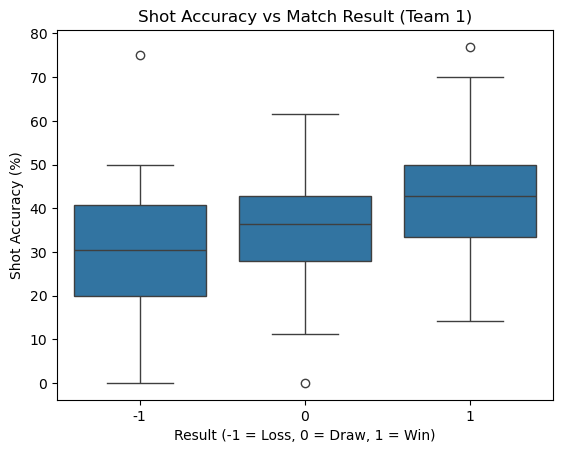

In [12]:
sns.boxplot(x='result', y='shot_accuracy_team1', data=df)
plt.title('Shot Accuracy vs Match Result (Team 1)')
plt.xlabel('Result (-1 = Loss, 0 = Draw, 1 = Win)')
plt.ylabel('Shot Accuracy (%)')
plt.savefig("../images/shot_accuracy_vs_match_result.png", dpi=300)
plt.show()

The **shot accuracy** plot indicates that winning teams tend to have slightly higher shooting accuracy than losing teams. Although the distributions overlap, the median accuracy for winning teams is higher, suggesting that successful teams are not only creating chances but also directing a greater proportion of their shots on target. 

In [13]:
df['goal_conversion_team1'] = (
    (df['number_of_goals_team1'] / 
    df['total_attempts_team1']) * 100
)

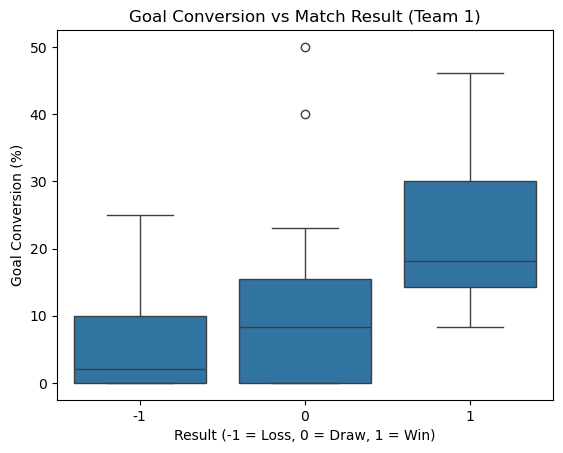

In [14]:
sns.boxplot(x='result', y='goal_conversion_team1', data=df)
plt.title("Goal Conversion vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Goal Conversion (%)")
plt.savefig("../images/goal_conversion_vs_match_result.png", dpi=300)
plt.show()

The **goal conversion rate** shows the clearest difference between outcomes. Winning teams have a significantly higher goal conversion rate than losing teams. This suggests that the most important factor among the three metrics is the **ability to convert chances into goals**, rather than simply creating many attempts. 

Overall, these results suggest that while creating shots is important, **finishing efficiency - particularly goal covnrsion - plays a stronger role in determining match outcomes.** Teams that are more effective at converting their opportunities into goals are more likely to win matches. 

### Defensive Performance vs Match Outcomes
In addition to attacking efficiency, defensive performance may also influence match outcomes. 
This section examines defensive metrics such as forced turnovers, defensive pressures applied, and goal preventions to evaluate whether stronger defensive activity is associated with winning matches. 

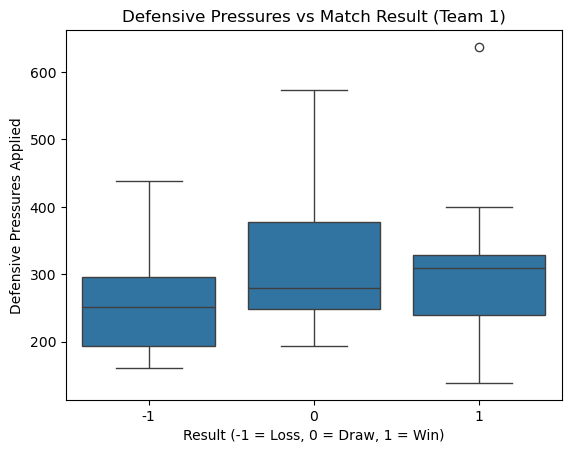

In [15]:
sns.boxplot(x="result", y="defensive_pressures_applied_team1", data=df)

plt.title("Defensive Pressures vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Defensive Pressures Applied")
plt.savefig("../images/defensive_pressures_vs_match_result.png", dpi=300)
plt.show()

The defensive metrics show moderate variation across match outcomes. Winning teams generally exhibit slightly higher values of **defensive pressures** applied, suggesting that teams that press more actively may disrupt their opponents' build-up play and regain possession more effectively. 

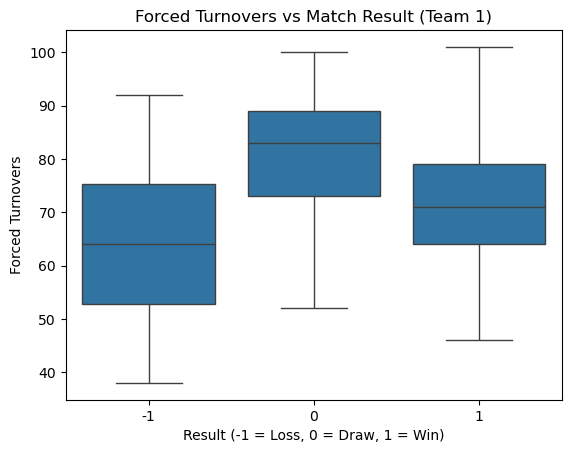

In [16]:
sns.boxplot(x="result", y="forced_turnovers_team1", data=df)
plt.title("Forced Turnovers vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Forced Turnovers")
plt.savefig("../images/forced_turnovers_vs_match_result.png", dpi=300)
plt.show()

The **forced turnovers** plot shows that teams involved in draws tend to have the highest median number of forced turnovers, while both winning and losing teams show slightly lower values. This suggests that while forcing turnovers can indicate strong defensive activity, it does not necessarily translate directly into winning matches. Nonetheless, the winning teams had slightly higher forced turnovers compared to the losing ones, suggesting that they allow less attacks to their goal. 

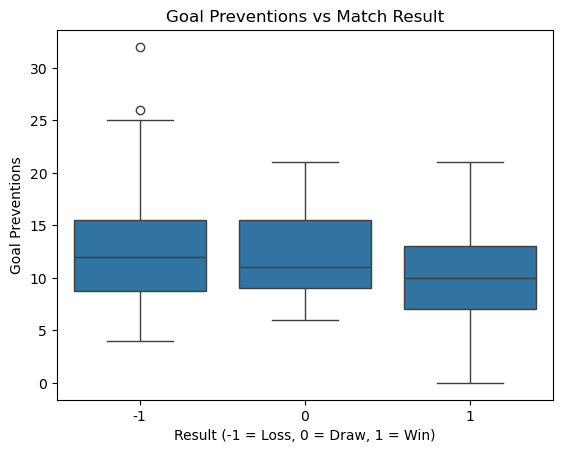

In [17]:
sns.boxplot(x='result', y='goal_preventions_team1', data=df)
plt.title("Goal Preventions vs Match Result")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Goal Preventions")
plt.savefig("../images/goal_preventions_vs_match_result.png", dpi=300)
plt.show()

Finally, the **goal preventions** metric appeas to be slightly higher for teams that lose matches. This likely reflects that losing teams may spend more time defending and therefore perform more defensive interventions, rather than indicating stronger defensive performance. 

Overall, these results suggest that while defensive activity plays an important role in matches, **defensive metrics alone do not clearly distinguish winning teams from losing teams**, and match outcomes are likely determined by a combination of both attacking efficiency and defensive performance. 

### Ball Controlvs Match Outcome 
This section examines how ball control relates to match outcomes. 
The analysis focuses on possession, total passes, completed passes, and pass accuracy. 

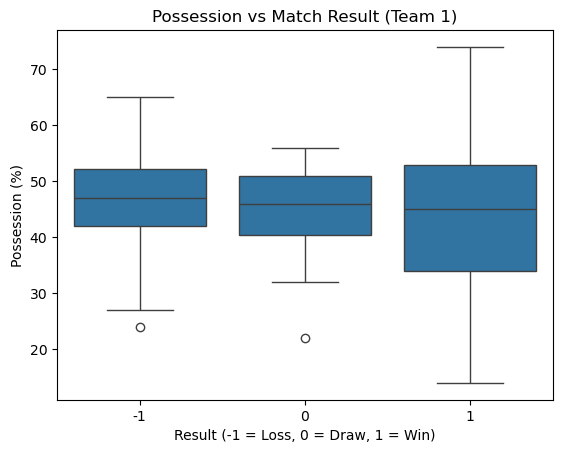

In [18]:
sns.boxplot(x='result', y='possession_team1', data=df)
plt.title('Possession vs Match Result (Team 1)')
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Possession (%)")
plt.savefig("../images/possession_vs_match_result.png", dpi=300)
plt.show()

The boxplot indicates that possession does not stronly correlate with winning. Winning teams display a wide range of possession values, indicating that controlling possession alone is not a reliable predictor of match success. 

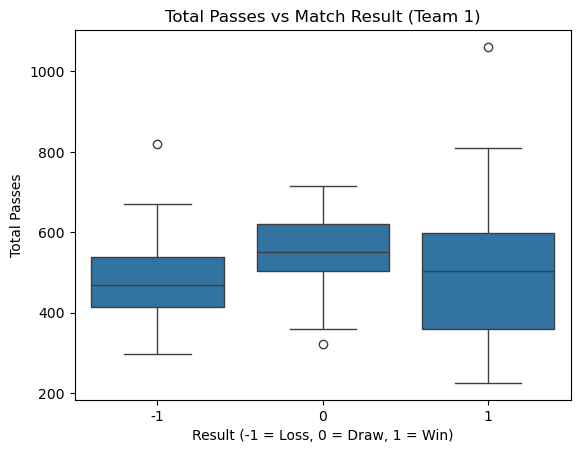

In [19]:
sns.boxplot(x="result", y="passes_team1", data=df)
plt.title("Total Passes vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Total Passes")
plt.savefig("../images/total_passes_vs_match_result.png", dpi=300)
plt.show()

The **total passes** plot shows that teams involved in draws tend to have the highest median number of passes, while winning teams display a wider distribution. This suggests that while high passing volume may indicate greater ball control, it does not necessarily lead to a victory. 

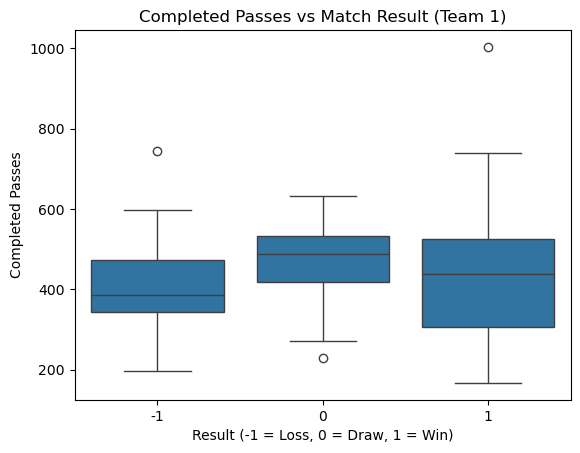

In [20]:
sns.boxplot(x="result", y="passes_completed_team1", data=df)
plt.title("Completed Passes vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Completed Passes")
plt.savefig("../images/completed_passes_vs_match_result.png", dpi=300)
plt.show()

Similarly, the **completed passes** plot shows a slightly higher median for matches that ended with a draw compared to wins and losses. This indicates that teams maintaining a high level of passing activity may focus on maintaining possession rather than creating decisive scoring opportunity.

In [21]:
df["pass_accuracy_team1"] = (
    (df["passes_completed_team1"] / 
    df["passes_team1"]) * 100
)

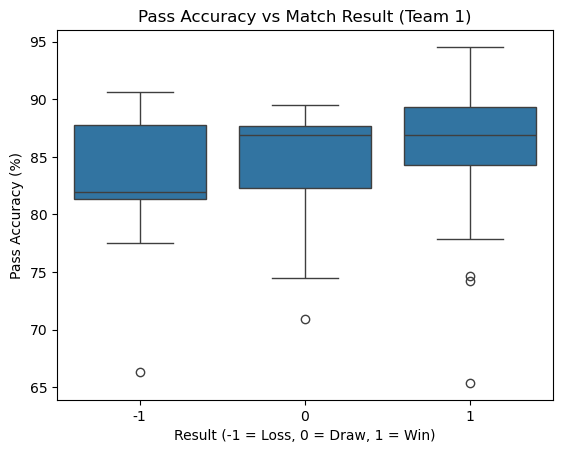

In [22]:
sns.boxplot(x="result", y="pass_accuracy_team1", data=df)
plt.title("Pass Accuracy vs Match Result (Team 1)")
plt.xlabel("Result (-1 = Loss, 0 = Draw, 1 = Win)")
plt.ylabel("Pass Accuracy (%)")
plt.savefig("../images/pass_accuracy_vs_match_result.png", dpi=300)
plt.show()

Finally, the **pass accuracy** plot shows a small increase in median accuracy for winning teams compared to losing teams. However, the distributions largely overlap, suggesting that while accurate passing may contribute to overall team performance, it is not a strong standalone predictor of match outcomes. 

Overall, these results suggest that **passing volume and possession-based control do not strongly determine match outcomes**. Instead, match success appears to depend more on **how effectively teams convert attacking opportunities**, as seen in the earlier analysis of shot accuracy and goal conversion. 

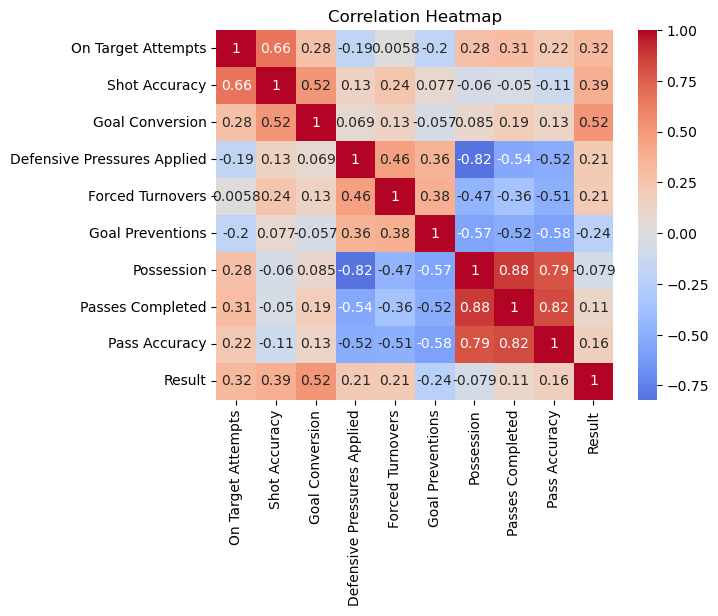

In [23]:
columns = [
    "on_target_attempts_team1", 
    "shot_accuracy_team1", 
    "goal_conversion_team1", 
    "defensive_pressures_applied_team1", 
    "forced_turnovers_team1", 
    "goal_preventions_team1",
    "possession_team1", 
    "passes_completed_team1", 
    "pass_accuracy_team1", 
    "result"
]

tick_lbl = [
    "On Target Attempts", 
    "Shot Accuracy", 
    "Goal Conversion", 
    "Defensive Pressures Applied", 
    "Forced Turnovers", 
    "Goal Preventions", 
    "Possession", 
    "Passes Completed", 
    "Pass Accuracy", 
    "Result"
]

# Correlation Matrix
corr_matrix = df[columns].corr()

# Plot Heatmap
sns.heatmap(corr_matrix, xticklabels=tick_lbl, yticklabels=tick_lbl, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

The correlation heatmap highlights how different performance metrics relate to match outcomes. Among the three main categories analyzed - attacking efficiency, defensive activity, and ball control - **attacking metrics show the strongest correlation with winning**. In particular, goal conversion rate and shot accuracy display the highest positive correlations with match results, indicating that teams that finish their chances more effectively are more likely to win matches. 

Defensive metrics such as defensive pressures and forced turnovers show **weaker positive relationships** with match outcomes, suggesting that while defensive activity contributes to overall performance, it is not as strongly associated with winning as attacking efficiency.

Ball control metrics - including possession, total passes, and pass accuracy - show **the weakest correlation with match outcomes**. This suggests that simply maintaining possession or completing a high number of passes does not necessarily translate into winning matches. 

Overall, the relatively moderate correlation values across all metrics indicate that **no single factor determines match success**. Instead, winning appears to result from a combination of offensive efficiency, defensive effectiveness, and overall team performance during the match. 

## Multinomial Logistic Regression Model
The multinomial logistic regression model was used to examine how different match statistics relate to the probability of a loss, draw, or win. Positive coefficients indicate that higher values of a features increase the likelihood of a particular outcome, while negative coefficients indicate the opposite. 

C:\Users\MAGICO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

          -1       0.60      0.60      0.60         5
           0       0.60      0.75      0.67         4
           1       0.67      0.50      0.57         4

    accuracy                           0.62        13
   macro avg       0.62      0.62      0.61        13
weighted avg       0.62      0.62      0.61        13

    on_target_attempts_team1  shot_accuracy_team1  goal_conversion_team1  \
-1                  0.033458            -0.285990              -0.407133   
 0                 -0.523831             0.094641              -0.187638   
 1                  0.490374             0.191349               0.594772   

    defensive_pressures_applied_team1  forced_turnovers_team1  \
-1                          -0.376240               -0.874776   
 0                           0.142939                0.899466   
 1                           0.233301               -0.024691   

    possession_team1  pass_accuracy_team1  
-1       

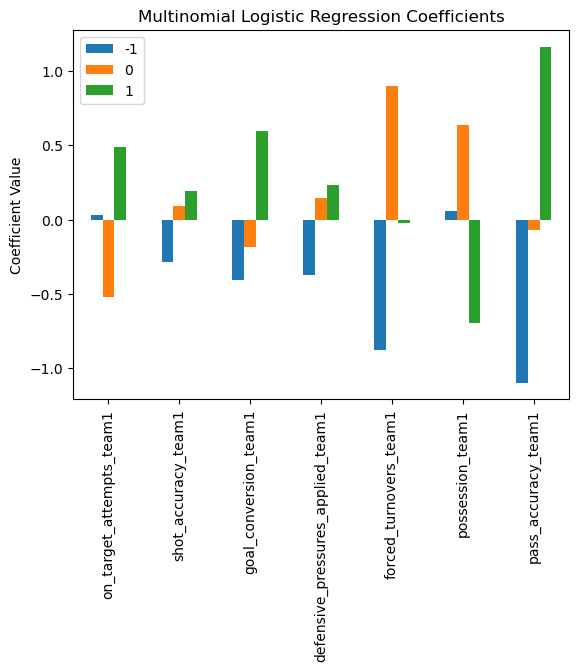

In [24]:
features = [
    "on_target_attempts_team1", 
    "shot_accuracy_team1", 
    "goal_conversion_team1", 
    "defensive_pressures_applied_team1", 
    "forced_turnovers_team1", 
    "possession_team1", 
    "pass_accuracy_team1"
]

X = df[features]
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    multi_class="multinomial", 
    solver="lbfgs", 
    max_iter=1000, 
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

coef_df = pd.DataFrame(
    model.coef_, 
    columns=features, 
    index=model.classes_
)
print(coef_df)

coef_df.T.plot(kind="bar")
plt.title("Multinomial Logistic Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.savefig("../images/multinomial_logistic_regression_coefficients.png", dpi=300, bbox_inches='tight')
plt.show()

#### Conclusion and Limitations
The model suggests that **attacking efficiency metrics**, particularly goal conversion and shots on target, are positively associated with winning. This supports the earlier exploratory analysis and correlation results, which indicated that the ability to convert chances into goals plays a key role in match success. 

Some features, such as **forced turnovers and pass accuracy**, display relatively larger coefficients in the regression model even though their individual correlations with match outcomes were not very strong. This occurs because regression evaluates the influence of each features while accounting for the presence of other variables, revealing relationships that may not appear in simple pairwise correlations. 

It is important to note that the dataset used in this analysis contains only 64 matches, which limits the statistical reliability of the model. For this reason, the logistic regression model is used primarily as a tool for **interpretation and exploratory insight rather than for building a highly accurate predictive model**. The results should therefore be interpreted as indicative patterns rather than definitive casual relationships. 

Overall, the regression results reinforce the earlier findings that match outcomes are influenced by a combination of attacking efficiency, defensive actions, and ball control, rather than by a single metric alone. 